In [1]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import tensorflow as tf

MAIN_DIR = "/home/onuro/code/simonwilliams32/MRI_project"

FINAL_DATASET_DIR = os.path.join(MAIN_DIR, "raw_data", "final_brain_tumor_preprocessed_dataset")

TRAIN_DIR = FINAL_DATASET_DIR + "/train"
VAL_DIR = FINAL_DATASET_DIR + "/val"
TEST_DIR = FINAL_DATASET_DIR + "/test"
EXTERNAL_VAL_DIR = FINAL_DATASET_DIR + "/external_val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

class_names = ["glioma", "meningioma", "notumor", "pituitary"]
IMAGE_EXTS = (".png", ".jpg", ".jpeg")

##### Check for / convert colorized images into grayscale

def is_grayscale(path):
    """Returns True if image is black & white (all RGB channels equal)."""
    try:
        img = Image.open(path).convert("RGB")
        arr = np.array(img)
        return np.array_equal(arr[:, :, 0], arr[:, :, 1]) and np.array_equal(arr[:, :, 1], arr[:, :, 2])
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return None

results = []

for split in os.listdir(FINAL_DATASET_DIR):
    split_path = os.path.join(FINAL_DATASET_DIR, split)
    if not os.path.isdir(split_path):
        continue

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue

        for fname in os.listdir(class_path):
            if not fname.lower().endswith(IMAGE_EXTS):
                continue
            fpath = os.path.join(class_path, fname)
            gray = is_grayscale(fpath)
            results.append({
                "split": split,
                "class": class_name,
                "filename": fname,
                "path": fpath,
                "is_grayscale": gray
            })

df = pd.DataFrame(results)

print(f"Total images checked: {len(df)}")
print(f"Grayscale: {(df['is_grayscale'] == True).sum()}")
print(f"Colormapped/Color: {(df['is_grayscale'] == False).sum()}")
print(f"Errors/unreadable: {df['is_grayscale'].isna().sum()}")

print("\nBreakdown by split and class:")
summary = df.groupby(["split", "class"])["is_grayscale"].value_counts().unstack(fill_value=0)
print(summary)


def convert_to_grayscale_and_save(path):
    """Convert an image to grayscale (L), then save it back as 3-channel RGB
    so shape/format stays consistent with the rest of the pipeline."""
    try:
        img = Image.open(path).convert("RGB")
        gray = img.convert("L")
        gray_rgb = Image.merge("RGB", (gray, gray, gray))
        gray_rgb.save(path)
        return True
    except Exception as e:
        print(f"Error converting {path}: {e}")
        return False

# Only touch the ones flagged as colorized
to_fix = df[df["is_grayscale"] == False]
print(f"Converting {len(to_fix)} colorized images to grayscale...")

converted = 0
failed = 0
for path in to_fix["path"]:
    if convert_to_grayscale_and_save(path):
        converted += 1
    else:
        failed += 1

print(f"Converted: {converted}")
print(f"Failed: {failed}")


# load datasets

train_ds = tf.keras.utils.image_dataset_from_directory(
     TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=True, class_names=class_names
 )
val_ds = tf.keras.utils.image_dataset_from_directory(
     VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=False, class_names=class_names
 )
test_ds = tf.keras.utils.image_dataset_from_directory(
     TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=False, class_names=class_names
)

# external validation is not used for this model
""" external_val_ds = tf.keras.utils.image_dataset_from_directory(
     EXTERNAL_VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=False, class_names=class_names
 )
 """

print("Training paths prepared:")
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("EXTERNAL_VAL_DIR:", EXTERNAL_VAL_DIR)

I0000 00:00:1784545084.142169   40028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784545084.142869   40028 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784545084.193274   40028 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784545085.950749   40028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Total images checked: 14602
Grayscale: 14602
Colormapped/Color: 0
Errors/unreadable: 0

Breakdown by split and class:
is_grayscale      True
split class           
test  glioma       862
      meningioma   665
      notumor      260
      pituitary    404
train glioma      4018
      meningioma  3104
      notumor     1212
      pituitary   1886
val   glioma       862
      meningioma   665
      notumor      260
      pituitary    404
Converting 0 colorized images to grayscale...
Converted: 0
Failed: 0
Found 10220 files belonging to 4 classes.
Found 2191 files belonging to 4 classes.
Found 2191 files belonging to 4 classes.


E0000 00:00:1784545108.020815   40028 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training paths prepared:
TRAIN_DIR: /home/onuro/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/train
VAL_DIR: /home/onuro/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/val
TEST_DIR: /home/onuro/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/test
EXTERNAL_VAL_DIR: /home/onuro/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/external_val


In [2]:
# model with two targets
# we need to update labels
# labels are hot-one encoded. we need to find which encoding corresponds to notumour and convert it to healthy. all the rest are unhealthy
class_names = ["glioma", "meningioma", "notumor", "pituitary"]
notumor_index = class_names.index("notumor") # index 2

def to_binary_label(images, labels):
    # first, find the index where the label encoding is 1
    class_idx = tf.argmax(labels, axis=1)
    # if this index equals to the notumor_index, label as healthy
    # healthy (notumor) = 0, everything else (cancer) = 1
    binary_label = tf.cast(tf.not_equal(class_idx, notumor_index), tf.float32)
    binary_label = tf.expand_dims(binary_label, axis=1)
    return images, binary_label

train_ds_binary = train_ds.map(to_binary_label)
val_ds_binary = val_ds.map(to_binary_label)
test_ds_binary = test_ds.map(to_binary_label)
#external_val_ds_binary = external_val_ds.map(to_binary_label)

images, labels = next(iter(train_ds_binary))
print("Shape after grayscale conversion:", images.shape)
print(labels)


Shape after grayscale conversion: (32, 224, 224, 3)
tf.Tensor(
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]], shape=(32, 1), dtype=float32)


In [3]:
from tensorflow.keras.applications import efficientnet

AUTOTUNE = tf.data.AUTOTUNE
# EfficientNet requires a specific scaling, expects raw 0-255 input

def prepare_for_efficientnet(images, labels):
    images = efficientnet.preprocess_input(images)
    return images, labels

###### Train ######
train_ds_effnet_binary = train_ds_binary.map(prepare_for_efficientnet)
train_ds_effnet_binary = train_ds_effnet_binary.cache()
train_ds_effnet_binary = train_ds_effnet_binary.shuffle(1000)
train_ds_effnet_binary = train_ds_effnet_binary.prefetch(AUTOTUNE)

###### Validation ######
val_ds_effnet_binary = val_ds_binary.map(prepare_for_efficientnet)
val_ds_effnet_binary = val_ds_effnet_binary.prefetch(AUTOTUNE)

###### Test ######
test_ds_effnet_binary = test_ds_binary.map(prepare_for_efficientnet)
test_ds_effnet_binary = test_ds_effnet_binary.prefetch(AUTOTUNE)

""" ###### External validation ######
external_val_ds_effnet_multi = external_val_ds.map(prepare_for_efficientnet)
external_val_ds_effnet_multi = external_val_ds_effnet_multi.prefetch(AUTOTUNE)
 """


images, labels = next(iter(train_ds_effnet_binary))
print("Image batch shape:", images.shape) #(32, 224, 224, 3)
print("Label batch shape:", labels.shape) #(32, 1)
print(labels[:5])


W0000 00:00:1784545110.067804   40247 png_io.cc:96] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 1)
tf.Tensor(
[[1.]
 [0.]
 [0.]
 [1.]
 [1.]], shape=(5, 1), dtype=float32)


W0000 00:00:1784545112.885995   40247 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


In [4]:
import tensorflow as tf
tf.keras.backend.clear_session()

base_model = efficientnet.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


In [5]:
from keras import layers, models


def add_last_layers_binary(base_model):
    '''Take a pre-trained model, set its parameters as non-trainable, and add additional trainable layers'''
    base_model.trainable = False

    pooling_layer = layers.GlobalAveragePooling2D()
    dense_layer = layers.Dense(64, activation="relu")
    dropout_layer = layers.Dropout(0.4)
    prediction_layer = layers.Dense(1, activation="sigmoid") # binary classification

    model = tf.keras.Sequential([
        base_model,
        pooling_layer,
        dense_layer,
        dropout_layer,
        prediction_layer
    ])
    return model


In [6]:
from tensorflow.keras import optimizers

def build_model_binary(base_model):
    model = add_last_layers_binary(base_model)
    model.compile(
        loss="binary_crossentropy", # this is for binary prediction
        optimizer=optimizers.Adam(learning_rate=1e-4),
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision"),
        ]
    )
    return model

model = build_model_binary(base_model)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,131,620 (15.76 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor="val_recall",
    mode="max",
    patience=3,
    restore_best_weights=True
)


In [9]:
from sklearn.utils.class_weight import compute_class_weight

y_train = []
for images, labels in train_ds_binary:
    y_train.extend(labels.numpy().flatten())
y_train = np.array(y_train)

healthy_count = int((y_train == 0).sum())
cancer_count = int((y_train == 1).sum())
print("Healthy (0):", healthy_count)
print("Cancer (1):", cancer_count)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

W0000 00:00:1784545116.443314   40296 png_io.cc:96] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
W0000 00:00:1784545119.054425   40287 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


Healthy (0): 1212
Cancer (1): 9008
{0: np.float64(4.2161716171617165), 1: np.float64(0.5672735346358793)}


In [10]:
history = model.fit(
    train_ds_effnet_binary,
    validation_data=val_ds_effnet_binary,
    epochs=5,
    callbacks=[es],
    class_weight=class_weight_dict,
)


Epoch 1/5


320/320 ━━━━━━━━━━━━━━━━━━━━ 263s 792ms/step - accuracy: 0.9375 - loss: 0.2361 - precision: 0.9859 - recall: 0.9425 - val_accuracy: 0.9804 - val_loss: 0.0784 - val_precision: 0.9948 - val_recall: 0.9829
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 314s 982ms/step - accuracy: 0.9738 - loss: 0.0954 - precision: 0.9956 - recall: 0.9746 - val_accuracy: 0.9840 - val_loss: 0.0525 - val_precision: 0.9953 - val_recall: 0.9865
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 309s 967ms/step - accuracy: 0.9779 - loss: 0.0745 - precision: 0.9954 - recall: 0.9795 - val_accuracy: 0.9822 - val_loss: 0.0596 - val_precision: 0.9979 - val_recall: 0.9819
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 306s 956ms/step - accuracy: 0.9808 - loss: 0.0619 - precision: 0.9973 - recall: 0.9809 - val_accuracy: 0.9845 - val_loss: 0.0517 - val_precision: 0.9979 - val_recall: 0.9845
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 297s 927ms/step - accuracy: 0.9828 - loss: 0.0538 - precision: 0.9980 - recall: 0.9825 - val_accuracy: 0.9849 - val_los

In [11]:
model.evaluate(test_ds_effnet_binary)

69/69 ━━━━━━━━━━━━━━━━━━━━ 49s 703ms/step - accuracy: 0.9877 - loss: 0.0404 - precision: 0.9938 - recall: 0.9922


[0.04038335755467415,
 0.9876768589019775,
 0.9922320246696472,
 0.9937759041786194]

In [12]:
#model.evaluate(external_val_ds_effnet_multi)

classification Report
              precision    recall  f1-score   support

     healthy       0.94      0.95      0.95       260
      cancer       0.99      0.99      0.99      1931

    accuracy                           0.99      2191
   macro avg       0.97      0.97      0.97      2191
weighted avg       0.99      0.99      0.99      2191

Confusion Matrix


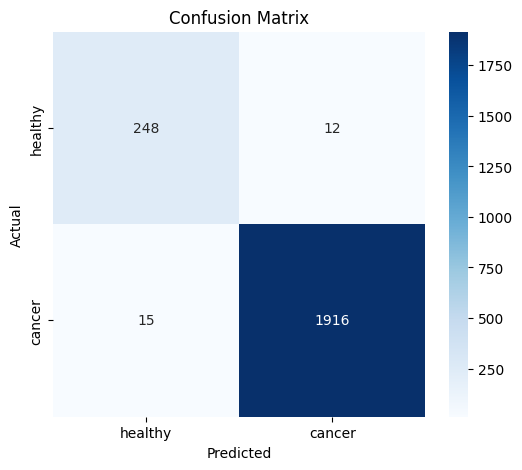

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model_binary(model, dataset):

    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().flatten())
        y_pred.extend((preds.flatten() > 0.5).astype(int))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("classification Report")
    print(classification_report(
        y_true, y_pred,
        target_names=["healthy", "cancer"],
        zero_division=0
    ))

    print("Confusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=["healthy", "cancer"], yticklabels=["healthy", "cancer"], cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix")
    plt.show()

    return y_true, y_pred


y_true_test, y_pred_test = evaluate_model_binary(model, test_ds_effnet_binary)

In [14]:
# this part is not needed as we don't use external validation
# External validation
# only has glioma/meningioma
#y_true_ext, y_pred_ext = evaluate_model_multi(model, external_val_ds_effnet_multi, dataset_name="External Validation")


In [15]:
# save the model

model.save("brain_tumor_model_binary_transferlearning.keras")